In [1]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Titanic-Dataset.csv')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
import os
print(os.listdir())

['.config', 'Titanic-Dataset.csv', 'Titanic-Dataset (1).csv', 'sample_data']


In [6]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (891, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare     

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


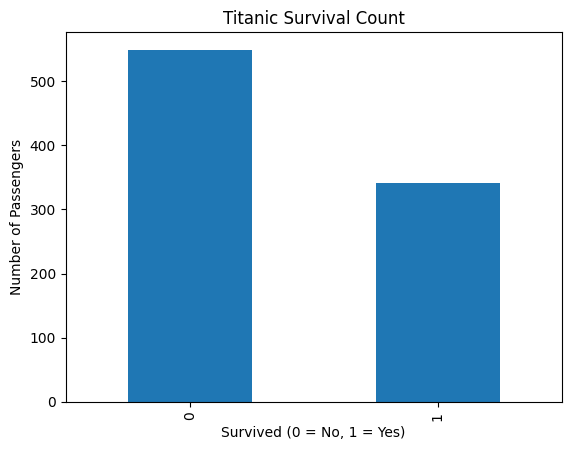

In [7]:
df['Survived'].value_counts().plot(
    kind='bar',
    title='Titanic Survival Count'
)

plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

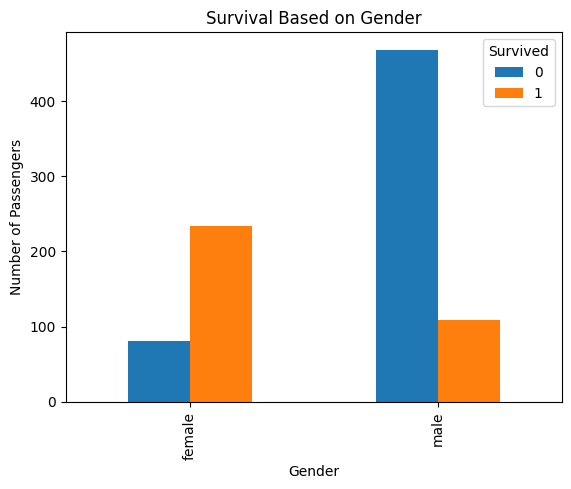

In [8]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')

plt.title('Survival Based on Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

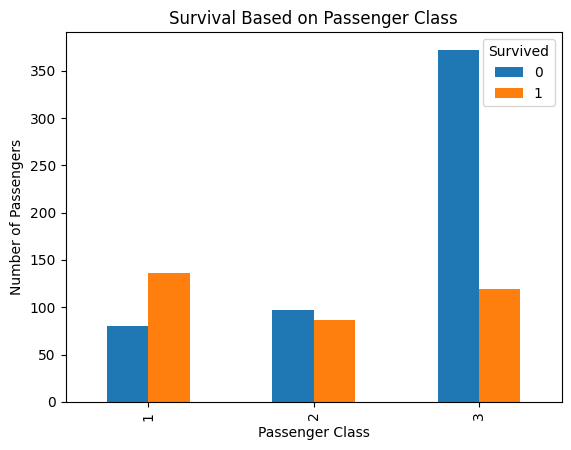

In [9]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')

plt.title('Survival Based on Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

In [10]:
data = df.copy()

In [11]:
data['Age'].fillna(data['Age'].median(), inplace=True)

data['Embarked'].fillna(
    data['Embarked'].mode()[0],
    inplace=True
)

data['Fare'].fillna(
    data['Fare'].median(),
    inplace=True
)

In [12]:
data.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1,
    inplace=True
)

data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [13]:
print(data.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [14]:
data['Sex'] = data['Sex'].map({
    'male': 0,
    'female': 1
})

data = pd.get_dummies(
    data,
    columns=['Embarked'],
    drop_first=True
)

data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [15]:
X = data.drop('Survived', axis=1)
y = data['Survived']

print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,False,False
2,3,1,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,True
4,3,0,35.0,0,0,8.0500,False,True


Target:


,Survived
0,0
1,1
2,1
3,1
4,0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (712, 8)
Testing Data: (179, 8)


In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results[name] = accuracy

    print(name)
    print("Accuracy:", round(accuracy * 100, 2), "%")
    print("-" * 40)

Logistic Regression
Accuracy: 80.45 %
----------------------------------------
Decision Tree
Accuracy: 82.12 %
----------------------------------------
Random Forest
Accuracy: 80.45 %
----------------------------------------
KNN
Accuracy: 65.92 %
----------------------------------------


In [18]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=['Model', 'Accuracy']
)

results_df['Accuracy (%)'] = results_df['Accuracy'] * 100

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

display(results_df)

,Model,Accuracy,Accuracy (%)
1,Decision Tree,0.821229,82.122905
0,Logistic Regression,0.804469,80.446927
2,Random Forest,0.804469,80.446927
3,KNN,0.659218,65.921788


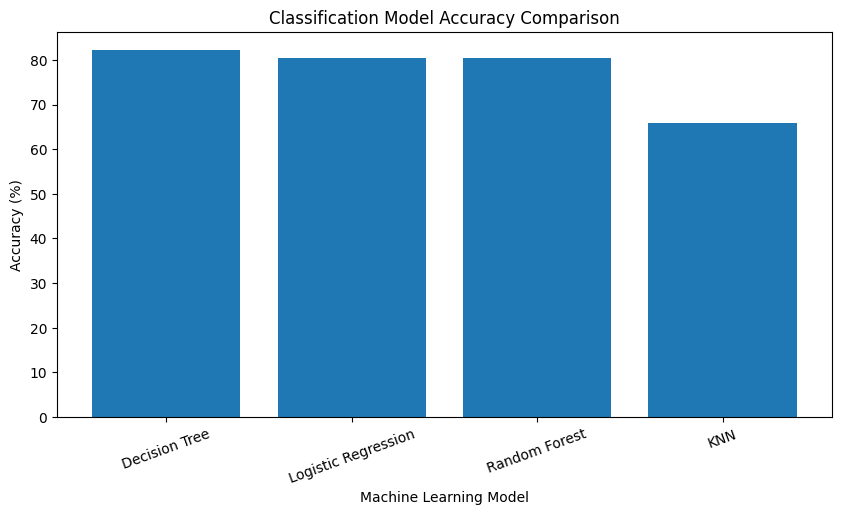

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df['Model'],
    results_df['Accuracy (%)']
)

plt.title('Classification Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy (%)')

plt.xticks(rotation=20)

plt.show()

In [20]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(grid_search.best_score_ * 100, 2), "%")

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}

Best Cross Validation Accuracy:
82.45 %


In [21]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print(
    "Final Test Accuracy:",
    round(accuracy_score(y_test, y_pred) * 100, 2),
    "%"
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Final Test Accuracy: 79.33 %

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179


Confusion Matrix:
[[96 14]
 [23 46]]


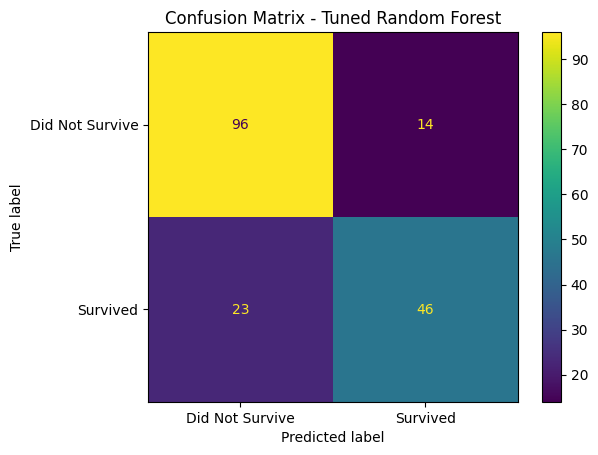

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Did Not Survive', 'Survived']
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

,Feature,Importance
1,Sex,0.332470
5,Fare,0.235780
2,Age,0.182747
0,Pclass,0.114734
3,SibSp,0.058776
4,Parch,0.036802
7,Embarked_S,0.024140
6,Embarked_Q,0.014550


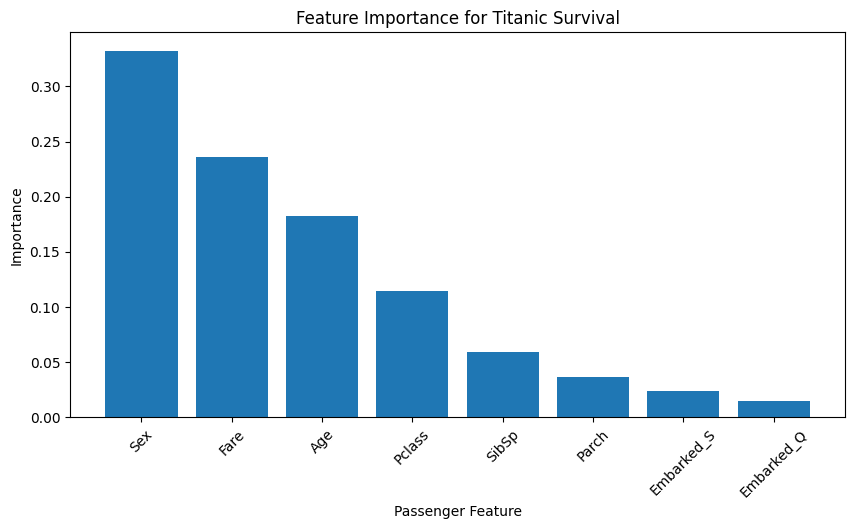

In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(importance)

plt.figure(figsize=(10, 5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance for Titanic Survival')
plt.xlabel('Passenger Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)

plt.show()

In [24]:
sample_passenger = pd.DataFrame({
    'Pclass': [1],
    'Sex': [1],
    'Age': [25],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [100],
    'Embarked_Q': [False],
    'Embarked_S': [True]
})

# Make sure column order matches training data
sample_passenger = sample_passenger[X.columns]

prediction = best_model.predict(sample_passenger)

if prediction[0] == 1:
    print("Prediction: The passenger would SURVIVE.")
else:
    print("Prediction: The passenger would NOT SURVIVE.")

Prediction: The passenger would SURVIVE.


Conclusion: In this project, the Titanic dataset was analyzed and preprocessed to build a machine-learning classification model for passenger survival prediction. Multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors, were evaluated. Hyperparameter tuning was performed using GridSearchCV to improve model performance. The final model was evaluated using accuracy, classification report, and confusion matrix. The analysis showed that factors such as gender, passenger class, age, and fare played important roles in determining survival probability.